# PLA–ChAT visual analysis: box and tissue-outline selections

Eight HALO exports represent **two analyses of the same four tissue regions**. The original jobs 4594–4597 used a box selection; new jobs 4999–5002 used a tissue outline, as described by the dataset owner. The new labels use `TDP43-Pfkp_tight` / `TDP43-Hk1_tight`; `pair_id` below explicitly links each to its original region.

The notebook defaults to **tissue-outline measurements**, with a paired comparison of both runs. These exports are not eight independent biological samples and are never pooled in the main figures.

The central images remain **object-coordinate reconstructions**: ChAT object counts provide a grayscale background and PLA measurements provide the heatmap. The CSVs contain neither microscopy pixels nor the actual tissue-outline polygons/area. An outlined analysis improves the selection context, but does not supply a drawable outline or a physical tissue-density denominator.

**Viewing and running:** all core results, comparisons, heatmaps, and interpretation appear below. The saved outputs can be viewed immediately. To recompute them, select the project `.venv` Python kernel and choose **Run All**. The setup cell refreshes the local analysis modules, including in an already-running kernel.

## How to read the figures

- **Counts** show exported detections per coordinate bin; they are not tissue density without an analyzed-area mask.
- **PLA with ChAT present** is a PLA-object fraction. Empty bins and bins below the support threshold are not the same thing as zero association.
- **Mean overlap** averages each PLA object's reported overlap percentage. **Area-weighted overlap** gives larger objects more influence.
- Every spatial position is a bounding-box midpoint in uncalibrated export coordinate units. Y is displayed in the exported orientation.
- The notebook retains zero diameters, zero-width boxes, and other review features. It does not silently filter them.

In [1]:
from pathlib import Path
import importlib, os, sys
from IPython.display import Markdown, display

HERE = Path.cwd().resolve()
REPO = next((p for p in [HERE, *HERE.parents] if (p / 'bio_visuals').is_dir() and (p / 'abstract.txt').is_file()), HERE)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
cache = REPO / 'outputs' / '.cache'
cache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(cache / 'matplotlib'))
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
# Run All also works in a kernel that imported an earlier version of this repo.
# Reload dependencies first, then rebind the functions used by the later cells.
importlib.invalidate_caches()
for module_name in ('data', 'spatial', 'plots', 'comparison', 'reporting'):
    importlib.reload(importlib.import_module(f'bio_visuals.{module_name}'))

from bio_visuals.data import load_data, summarize, quality_control, top_objects
from bio_visuals.plots import (setup_style, overview, ecdf_figures, overlap_composition,
    size_overlap, area_sensitivity, measurement_qc, area_concentration)
from bio_visuals.spatial import coordinate_overview, spatial_atlas, region_heatmap, bounding_box_zoom
from bio_visuals.comparison import (roi_summary_figure, paired_grid_data,
    paired_spatial_figure, exact_signature_comparison)
from bio_visuals.reporting import save_figure, export_tables, write_run_metadata
setup_style()
plt.rcParams['figure.constrained_layout.use'] = False

def show_and_save(fig, name, output_dir):
    display(fig)
    save_figure(fig, name, output_dir)
    plt.close(fig)

print('Analysis code refreshed. All core results and figures display in this notebook.')

Analysis code refreshed. All core results and figures display in this notebook.


In [2]:
# Change ROI_MODE to 'box' to regenerate the original selection's figures.
ROI_MODE = 'outline'
DATA_ROOT = REPO
SPATIAL_BIN_WIDTH = 250        # count reconstruction: export coordinate units
FRACTION_BIN_WIDTH = 1000      # coarser bins give local fractions more support
MIN_PLA_SUPPORT = 10           # a display-support choice, not significance
SPATIAL_SMOOTHING = 0          # no smoothing by default
COMPARISON_BIN_WIDTH = 500     # identical edges within each box/outline pair
FOCUS_PAIR = '24M_Pfkp-TDP43'
FOCUS_WINDOW = 150

if ROI_MODE not in ('box', 'outline'):
    raise ValueError("Choose ROI_MODE = 'box' or 'outline'; main figures must not pool runs.")
all_objects, all_manifest = load_data(DATA_ROOT, roi_mode='all', verify_hashes=True)
objects = all_objects.loc[all_objects.roi_mode == ROI_MODE].copy()
manifest = all_manifest.loc[all_manifest.roi_mode == ROI_MODE].copy()
FOCUS_JOB = manifest.loc[manifest.pair_id == FOCUS_PAIR, 'job'].iloc[0]
OUTPUT_ROOT = REPO / 'outputs' / ROI_MODE
COMPARISON_ROOT = REPO / 'outputs' / 'roi_comparison'
print(f'{len(all_manifest)} exports reviewed; {len(objects):,} rows selected for {ROI_MODE} figures.')
display(all_manifest[['job', 'roi_mode', 'pair_id', 'region', 'rows', 'sha256']])

8 exports reviewed; 1,067,281 rows selected for outline figures.


,job,roi_mode,pair_id,region,rows,sha256
0,4594,box,22M_Pfkp-TDP43,22M_Pfkp-TDP43 PLA,186343,83839e1e12719dd022d1e594a8effec80ba1059bcb3af2...
1,4595,box,24M_Pfkp-TDP43,24M_Pfkp-TDP43 PLA,297584,8013fb5553aebe4457dccfa42d13f52bb5497f186df544...
2,4596,box,22M_Hk1-TDP43,22M_Hk1-TDP43 PLA,238084,e1a16aada3ad0f589395f5567c64571d3a98c87d377187...
3,4597,box,24M_Hk1-TDP43,24M_Hk1-TDP43 PLA,356745,47a953163ff19d35e2c34ba3f483a9b38035b3dda29eb2...
4,4999,outline,22M_Pfkp-TDP43,22M_TDP43-Pfkp_tight,184684,9f77bd5d8f148edd95e8035445d2c22d46218ed9e5bc6f...
5,5000,outline,24M_Pfkp-TDP43,24M_TDP43-Pfkp_tight,295677,4a05d72249ab4b9f5a55ae90173078664f39fc8287c24f...
6,5001,outline,22M_Hk1-TDP43,22M_TDP43-Hk1_tight,237144,2e4e329f0623bd2bb3407cf4a1cee8d28460d76308fe89...
7,5002,outline,24M_Hk1-TDP43,24M_TDP43-Hk1_tight,349776,1ba6bbfc4ca4a37ac075783b31255795a0c2d6ebc708ca...


## 1. Audit the exports before interpreting them

The object type is the primary denominator decision. A PLA-present flag can occur on a ChAT row, so counting the flag alone would mix object populations.

In [3]:
summary_all = summarize(all_objects)
qc_all = quality_control(all_objects)
summary = summary_all.loc[summary_all.roi_mode == ROI_MODE].copy()
qc = qc_all.loc[qc_all.job.isin(manifest.job)].copy()
pla_summary = summary.loc[summary.object_type == 'PLA'].copy()
display(pla_summary[['job', 'region', 'n_objects', 'other_marker_count', 'other_marker_pct',
                     'mean_object_overlap_pct', 'area_weighted_overlap_pct']])
display(qc_all[['job', 'n_objects', 'overlap_pct_formula_mismatch', 'overlap_presence_mismatch',
                'any_zero_diameter', 'zero_bbox_width_or_height']])

,job,region,n_objects,other_marker_count,other_marker_pct,mean_object_overlap_pct,area_weighted_overlap_pct
9,4999,22M_TDP43-Pfkp_tight,8412,4893,58.166904,44.528091,44.183562
11,5000,24M_TDP43-Pfkp_tight,7733,5470,70.735808,57.399379,50.671891
13,5001,22M_TDP43-Hk1_tight,14984,6402,42.725574,30.859149,37.408429
15,5002,24M_TDP43-Hk1_tight,41237,22710,55.071901,44.974086,43.153573


,job,n_objects,overlap_pct_formula_mismatch,overlap_presence_mismatch,any_zero_diameter,zero_bbox_width_or_height
0,4594,186343,0,0,2556,2383
1,4595,297584,0,0,2416,1980
2,4596,238084,0,0,4180,4045
3,4597,356745,0,0,14362,13001
4,4999,184684,0,0,2291,2136
5,5000,295677,0,0,2360,1926
6,5001,237144,0,0,4143,4007
7,5002,349776,0,0,13493,12222


## 1b. What changes when the tissue is outlined?

The comparisons explicitly pair 4594→4999, 4595→5000, 4596→5001, and 4597→5002. All deltas are **outline minus box**. Percent changes in counts and percentage-point changes in overlap are different units. No significance test treats these reruns as independent samples.

**Key results across the four paired regions:** the outlined exports contain **3,945 fewer PLA detections** and **7,530 fewer ChAT detections** in total. The PLA-object fraction with ChAT present changes by at most **1.83 percentage points** per region. The largest area-weighted overlap change occurs in **24M_Pfkp-TDP43** (**+5.43 percentage points**). Object counts and area-weighted overlap can change differently because larger detections contribute more to the area-based measure. These are descriptive changes between analyses of the same tissue, not evidence of a biological effect.

,Region,Box PLA count,Outline PLA count,Count change (%),Box PLA with ChAT (%),Outline PLA with ChAT (%),Association change (pp),Box area-weighted overlap (%),Outline area-weighted overlap (%),Area-weighted change (pp)
0,22M_Pfkp-TDP43,"9,112","8,412",-7.68,59.04,58.17,-0.88,43.08,44.18,1.11
2,24M_Pfkp-TDP43,"7,999","7,733",-3.33,68.91,70.74,1.83,45.24,50.67,5.43
4,22M_Hk1-TDP43,"15,282","14,984",-1.95,42.44,42.73,0.29,38.02,37.41,-0.61
6,24M_Hk1-TDP43,"43,918","41,237",-6.10,55.46,55.07,-0.38,43.51,43.15,-0.36


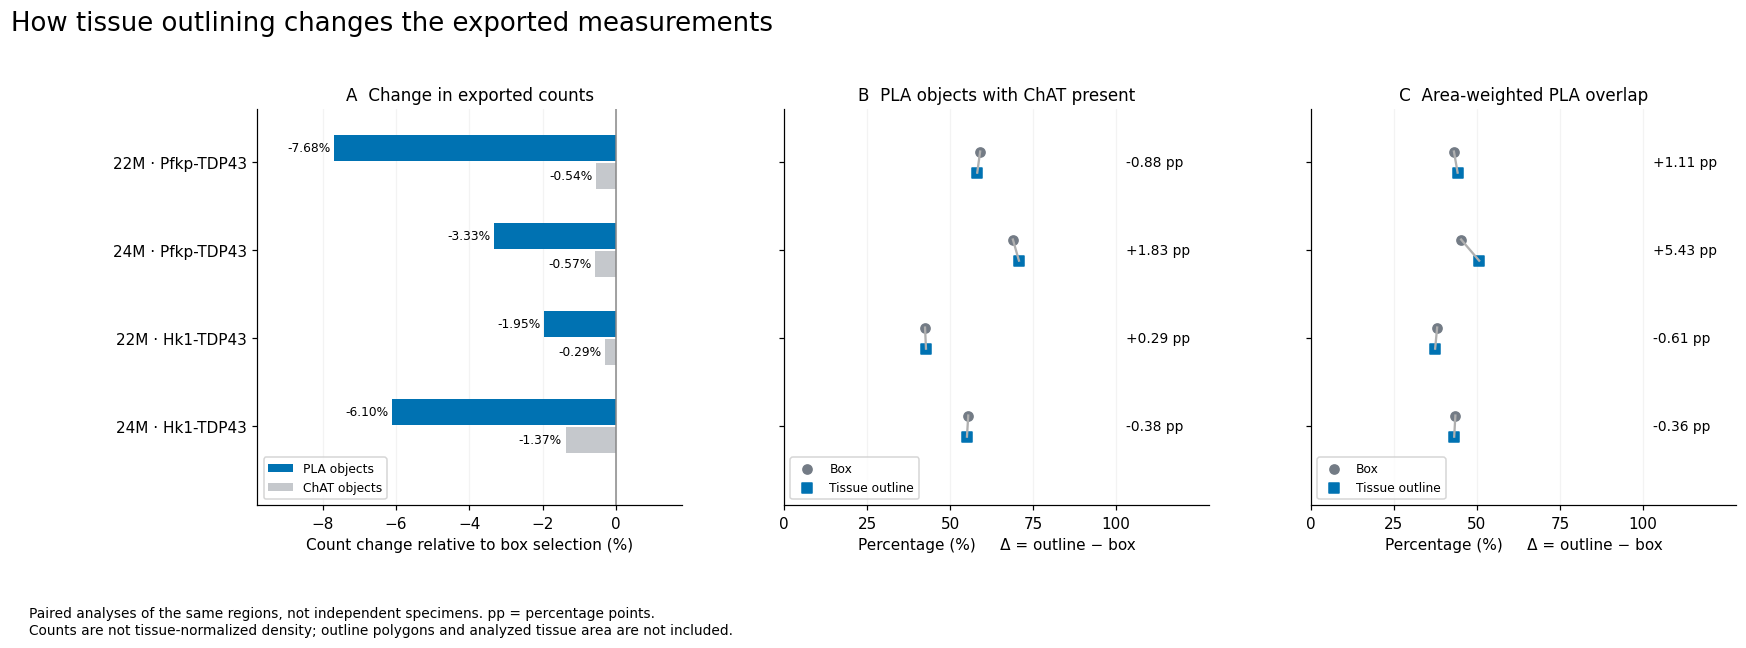

,pair_id,object_type,box_count,outline_count,identical_measurement_rows,box_rows_without_identical_signature,outline_rows_without_identical_signature,outline_identical_signature_pct
0,22M_Pfkp-TDP43,PLA,9112,8412,8225,887,187,97.776985
1,22M_Pfkp-TDP43,ChAT,177231,176272,161127,16104,15145,91.408165
2,24M_Pfkp-TDP43,PLA,7999,7733,7499,500,234,96.974008
3,24M_Pfkp-TDP43,ChAT,289585,287944,262076,27509,25868,91.016309
4,22M_Hk1-TDP43,PLA,15282,14984,14557,725,427,97.150294
5,22M_Hk1-TDP43,ChAT,222802,222160,203510,19292,18650,91.605149
6,24M_Hk1-TDP43,PLA,43918,41237,40793,3125,444,98.923297
7,24M_Hk1-TDP43,ChAT,312827,308539,290965,21862,17574,94.304124


Unmatched signatures may be changed measurements or detections, not necessarily different physical objects.


In [4]:
fig_roi, roi_table = roi_summary_figure(all_objects)
pla_comparison = roi_table.loc[roi_table.object_type == 'PLA'].copy()
count_totals = roi_table.groupby('object_type')[['box_count', 'outline_count']].sum()
pla_removed = int(count_totals.loc['PLA', 'box_count'] - count_totals.loc['PLA', 'outline_count'])
chat_removed = int(count_totals.loc['ChAT', 'box_count'] - count_totals.loc['ChAT', 'outline_count'])
largest_weighted_change = pla_comparison.loc[pla_comparison.weighted_overlap_delta.abs().idxmax()]
display(Markdown(
    f'**Key results across the four paired regions:** the outlined exports contain '
    f'**{pla_removed:,} fewer PLA detections** and **{chat_removed:,} fewer ChAT detections** in total. '
    f'The PLA-object fraction with ChAT present changes by at most '
    f'**{pla_comparison.association_delta.abs().max():.2f} percentage points** per region. '
    f'The largest area-weighted overlap change occurs in '
    f'**{largest_weighted_change.pair_id}** '
    f'(**{largest_weighted_change.weighted_overlap_delta:+.2f} percentage points**). '
    'Object counts and area-weighted overlap can change differently because larger detections '
    'contribute more to the area-based measure. These are descriptive changes between analyses '
    'of the same tissue, not evidence of a biological effect.'
))
display(pla_comparison[['pair_id', 'box_count', 'outline_count',
    'count_delta_pct', 'box_association', 'outline_association', 'association_delta',
    'box_weighted_overlap', 'outline_weighted_overlap', 'weighted_overlap_delta']].rename(columns={
        'pair_id': 'Region', 'box_count': 'Box PLA count', 'outline_count': 'Outline PLA count',
        'count_delta_pct': 'Count change (%)', 'box_association': 'Box PLA with ChAT (%)',
        'outline_association': 'Outline PLA with ChAT (%)', 'association_delta': 'Association change (pp)',
        'box_weighted_overlap': 'Box area-weighted overlap (%)',
        'outline_weighted_overlap': 'Outline area-weighted overlap (%)',
        'weighted_overlap_delta': 'Area-weighted change (pp)',
    }).style.format(precision=2, thousands=','))
show_and_save(fig_roi, '01_box_vs_outline_summary', COMPARISON_ROOT)

# Exact equality of all 16 non-ID object fields; preserves duplicate multiplicities.
signature_table = exact_signature_comparison(all_objects)
display(signature_table)
print('Unmatched signatures may be changed measurements or detections, not necessarily different physical objects.')

## 1c. Where do the two analyses differ?

Each figure shows box counts, outline counts, and their signed difference on **identical coordinate bins**. The two count panels share a color scale within each object type. Blue difference bins have fewer outline detections; red bins have more. A zero net change does not prove that the same objects were detected. No inferred polygon is drawn around the points.

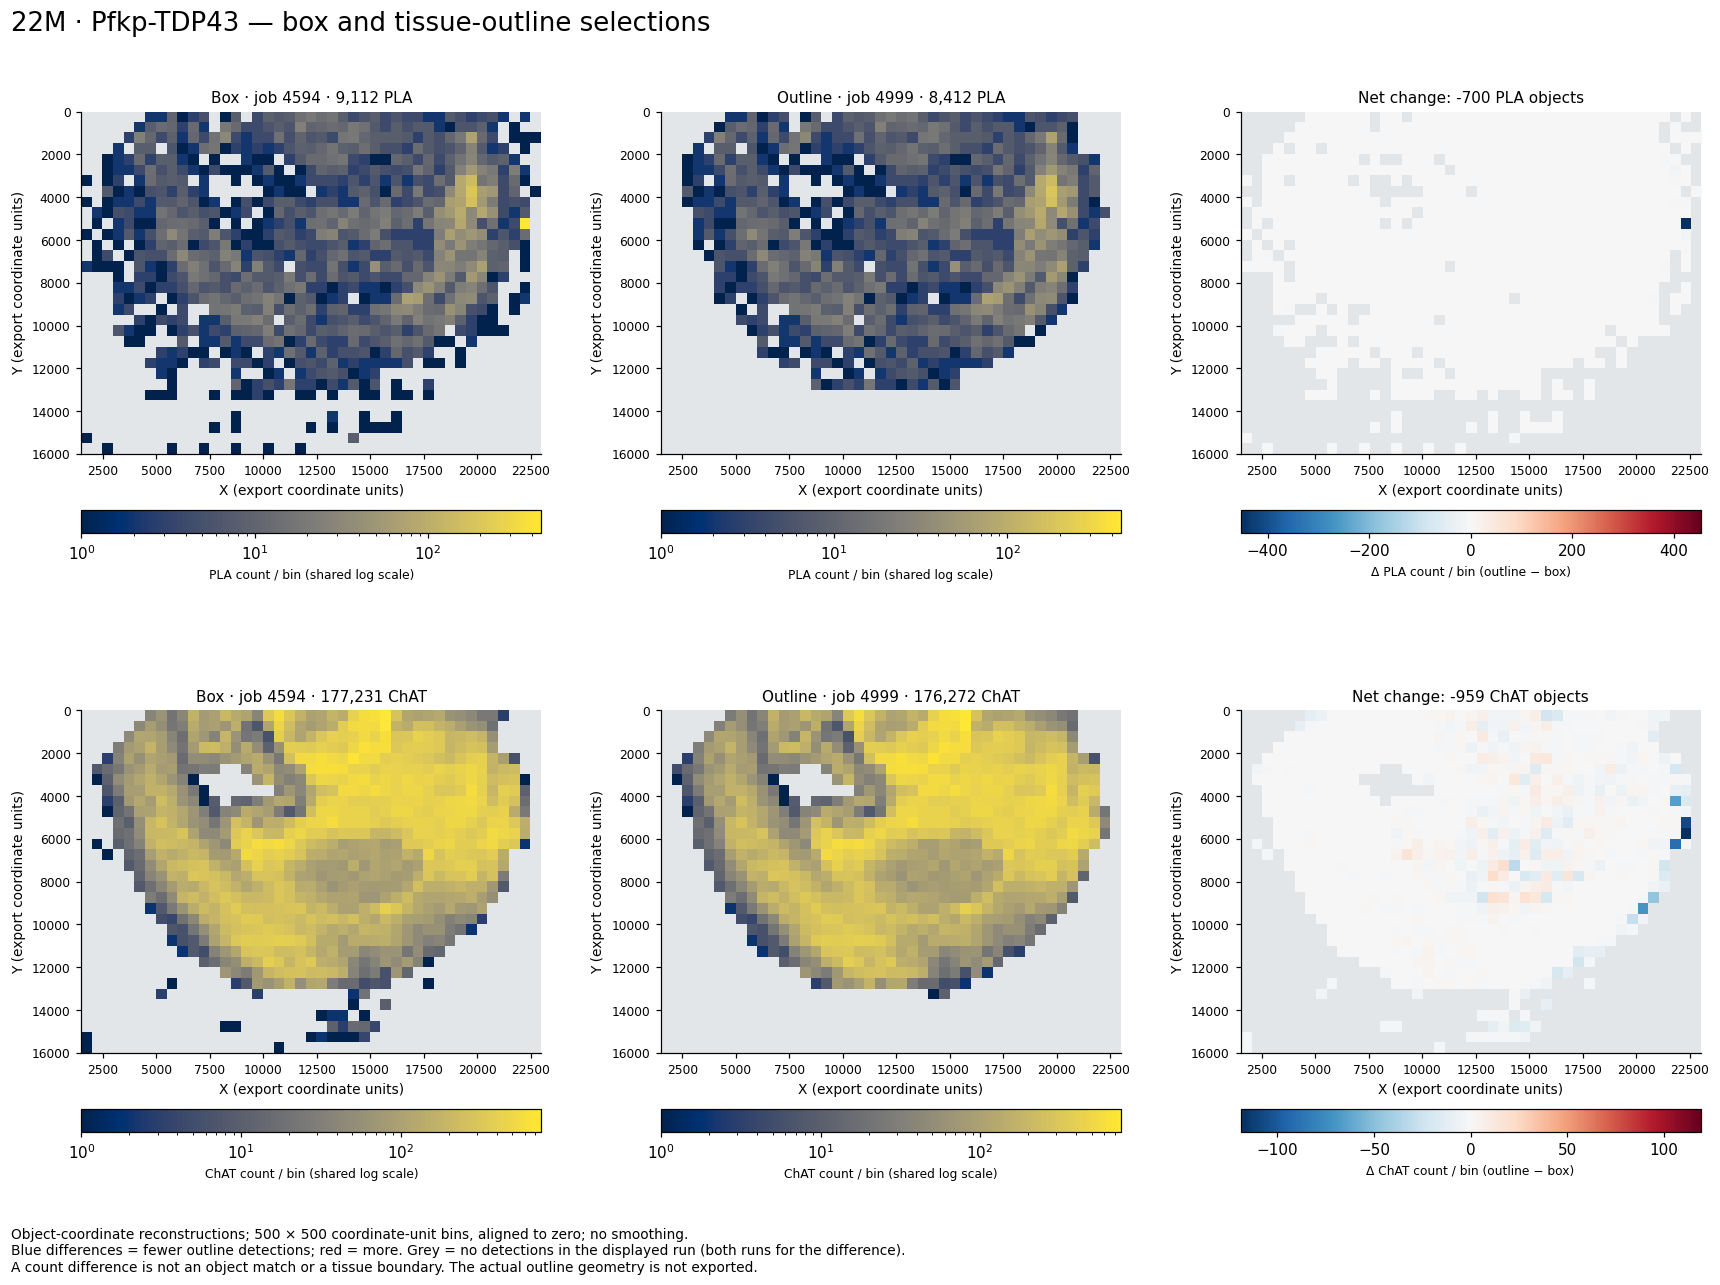

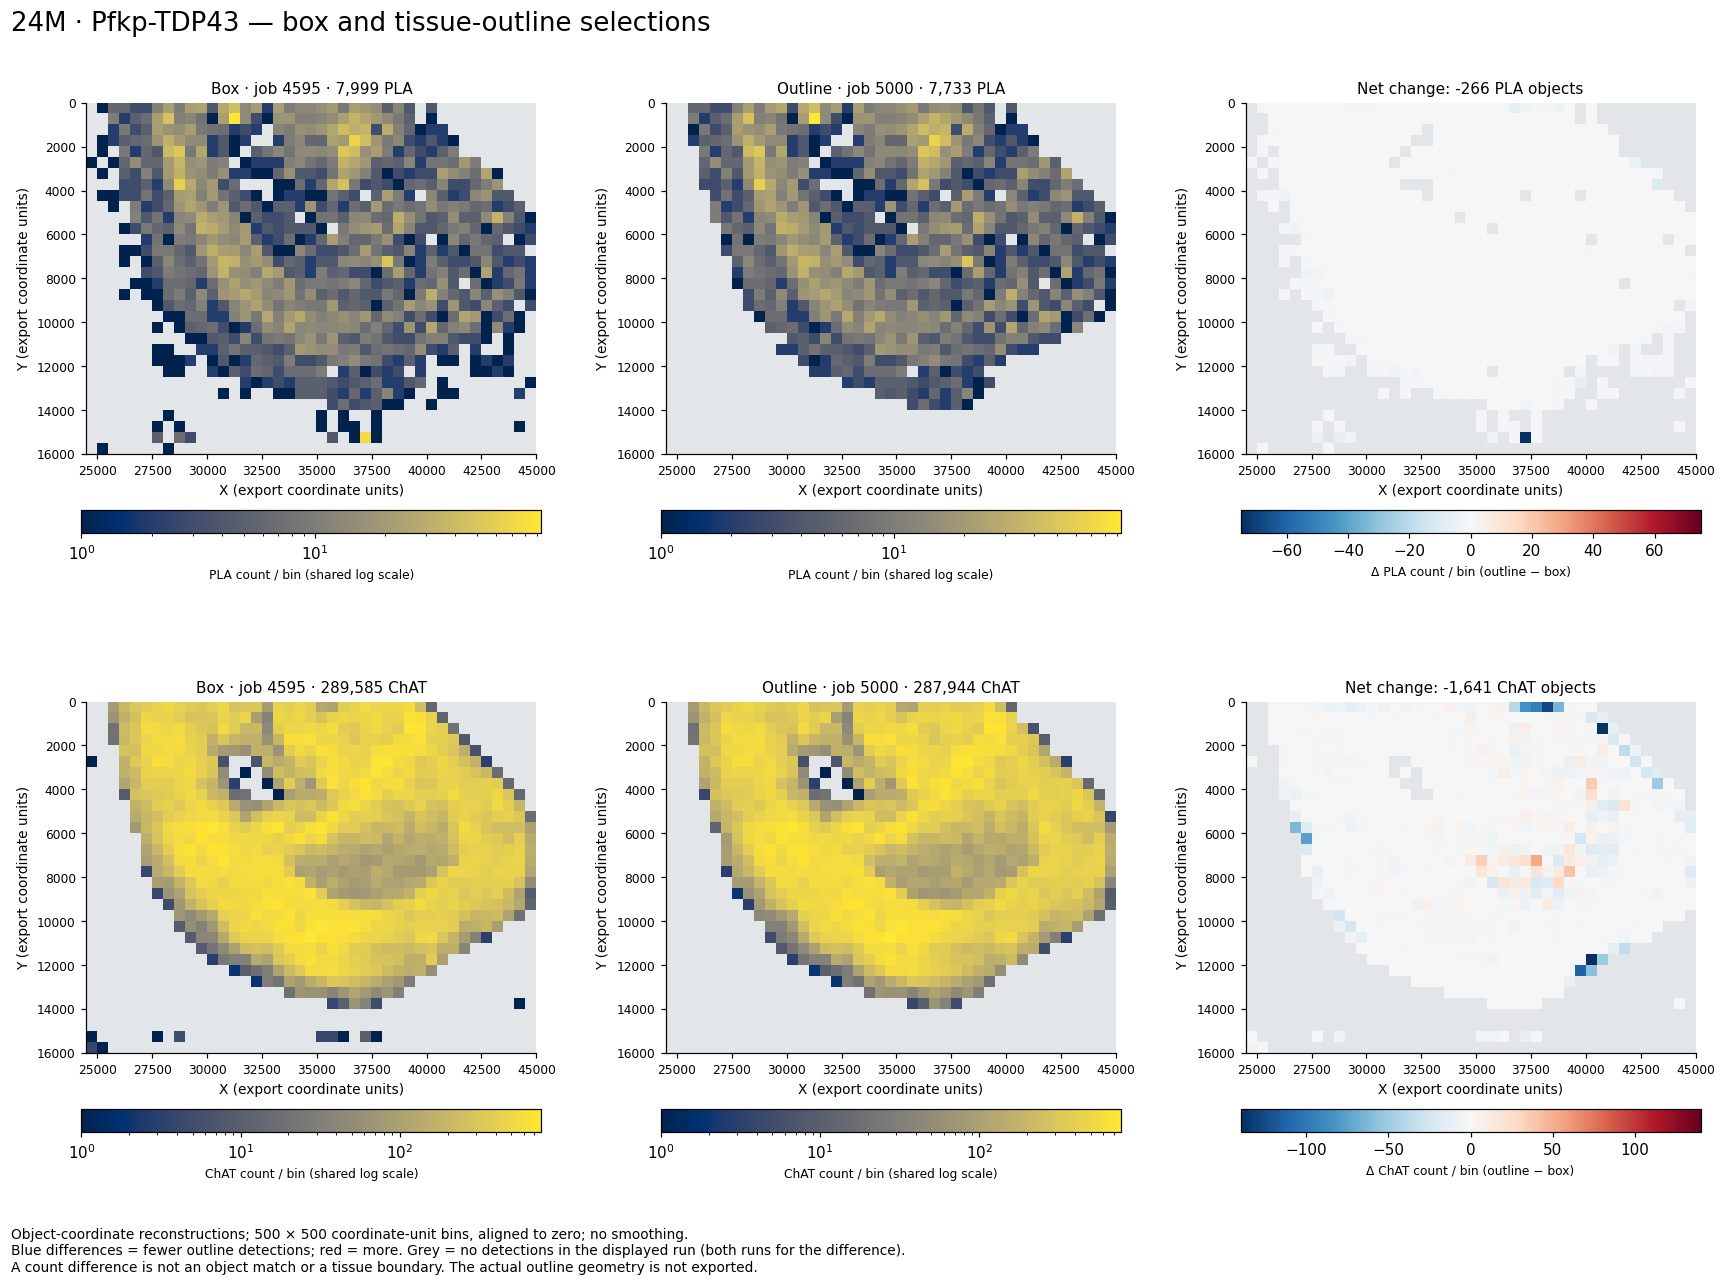

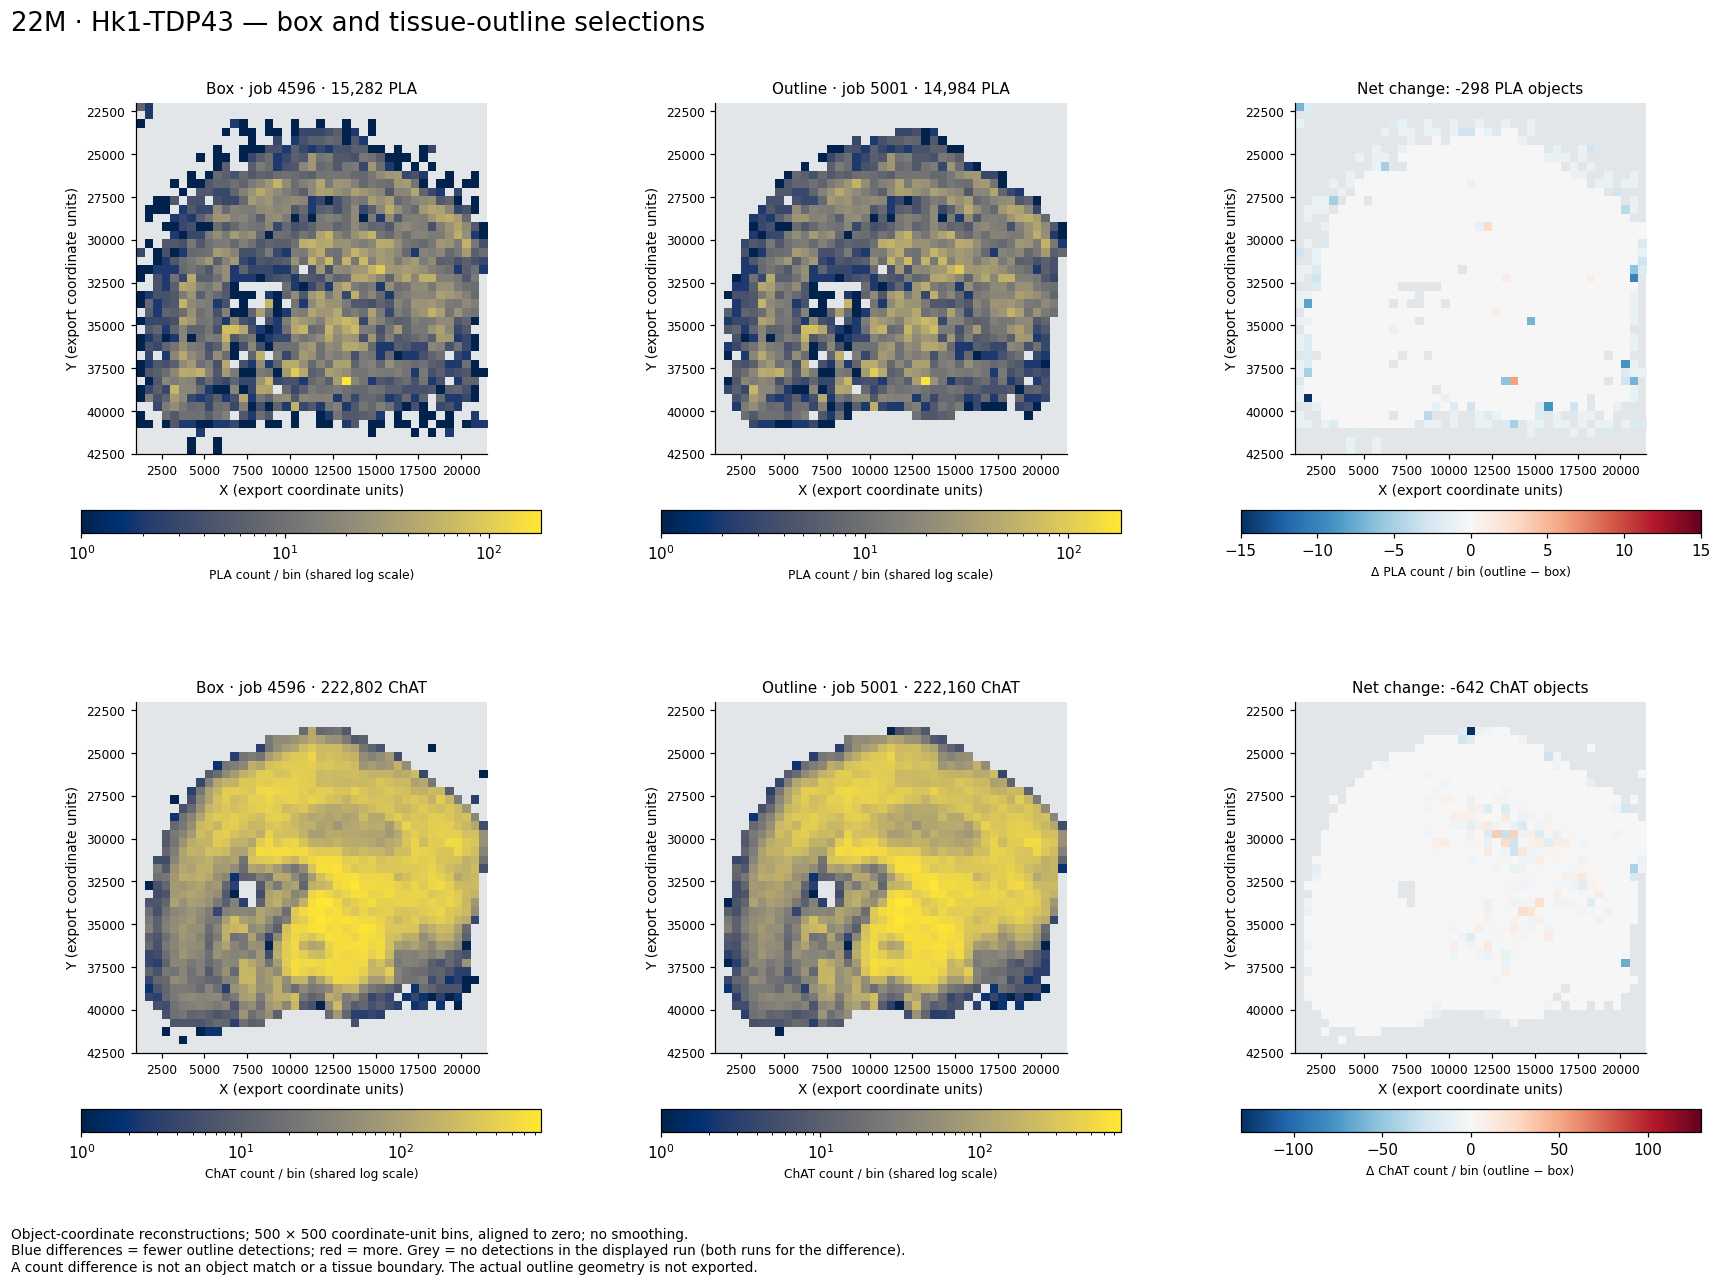

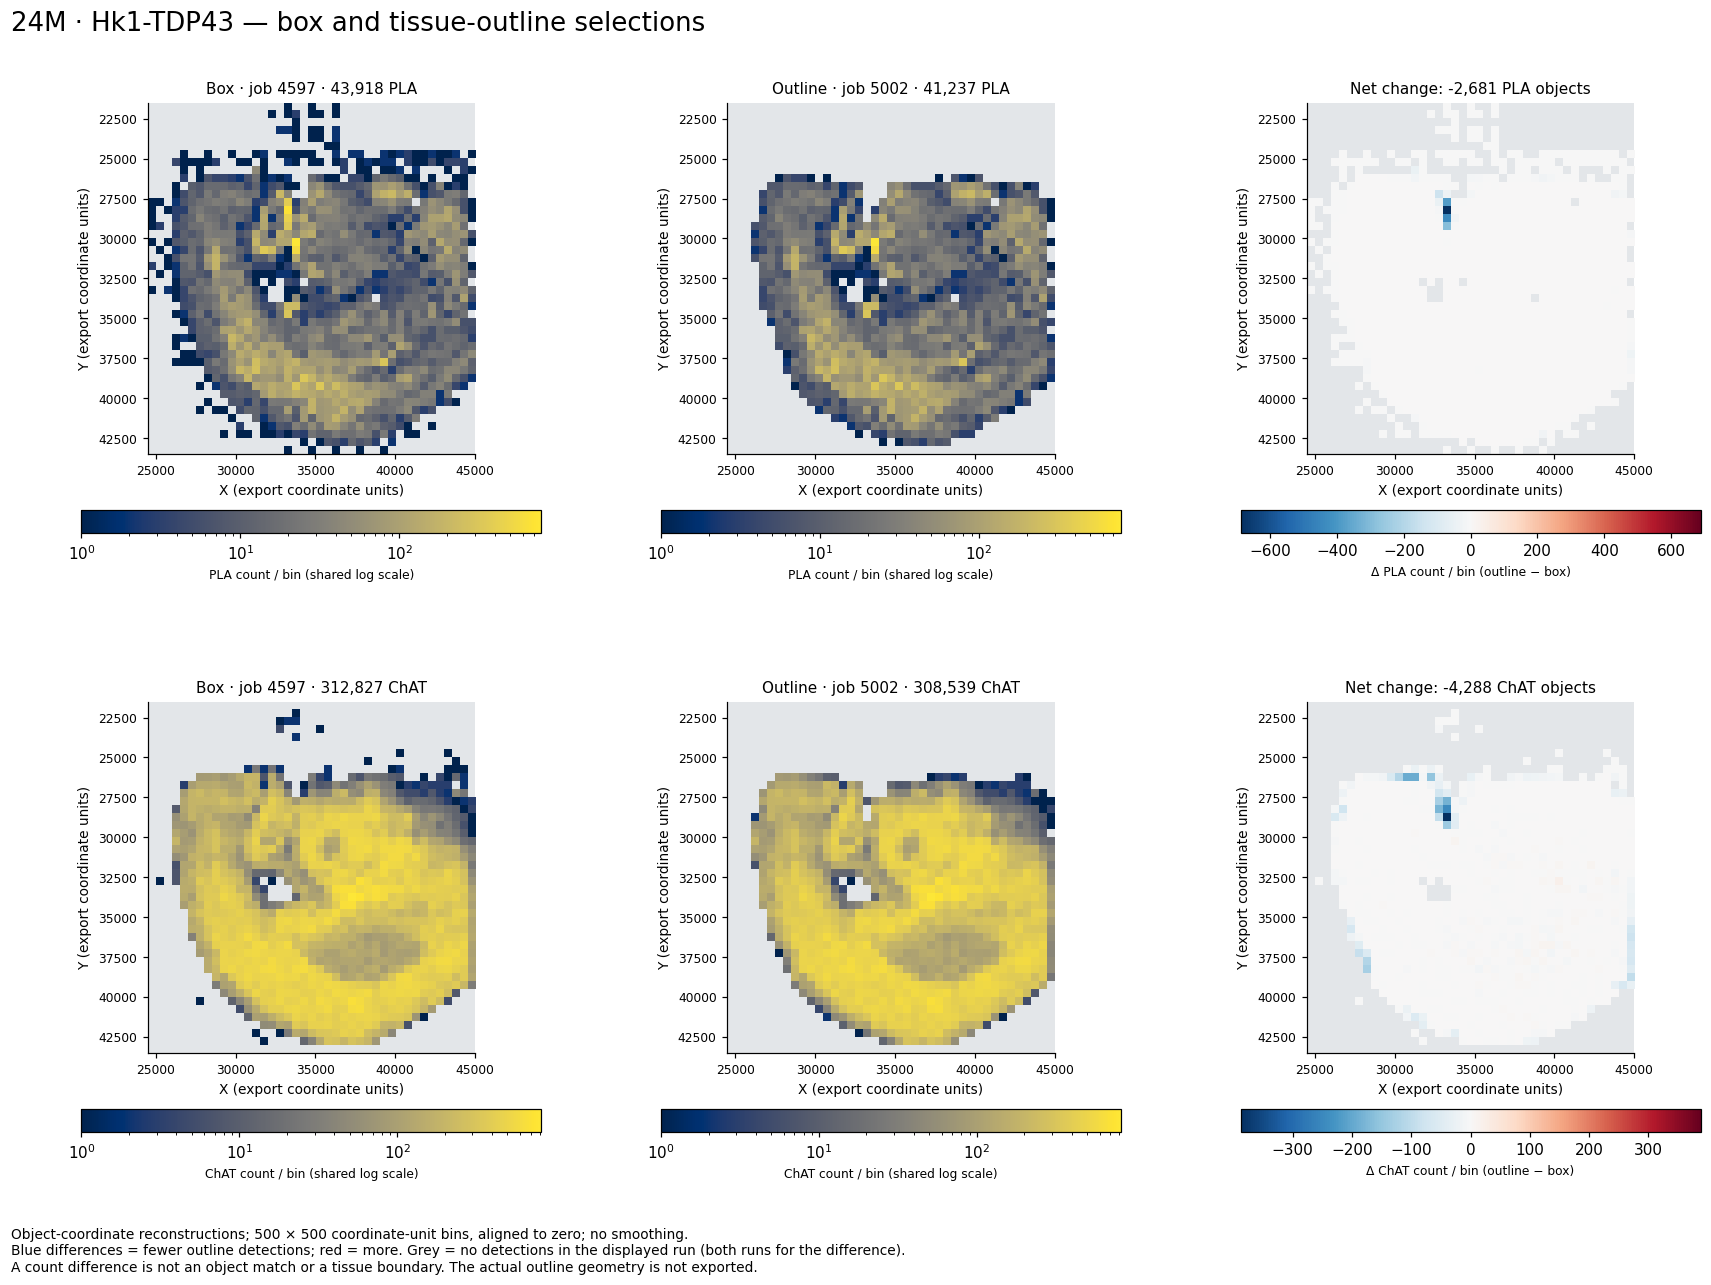

In [5]:
comparison_grid = paired_grid_data(all_objects, bin_width=COMPARISON_BIN_WIDTH)
for pair_id in all_manifest.pair_id.drop_duplicates():
    fig_pair = paired_spatial_figure(comparison_grid, pair_id)
    show_and_save(fig_pair, 'pair_' + pair_id, COMPARISON_ROOT)

## 2. Overview: counts and three overlap denominators

The third panel is intentionally a denominator check. These quantities answer different questions and should not be collapsed into one generic ‘colocalization’ percentage.

,job,region,label,pla_objects,chat_objects,pla_with_chat,pla_without_chat,pla_object_fraction_pct,pla_mean_overlap_pct,pla_area_weighted_overlap_pct
0,4999,22M_TDP43-Pfkp_tight,22M · Pfkp-TDP43,8412,176272,4893,3519,58.166904,44.528091,44.183562
1,5000,24M_TDP43-Pfkp_tight,24M · Pfkp-TDP43,7733,287944,5470,2263,70.735808,57.399379,50.671891
2,5001,22M_TDP43-Hk1_tight,22M · Hk1-TDP43,14984,222160,6402,8582,42.725574,30.859149,37.408429
3,5002,24M_TDP43-Hk1_tight,24M · Hk1-TDP43,41237,308539,22710,18527,55.071901,44.974086,43.153573


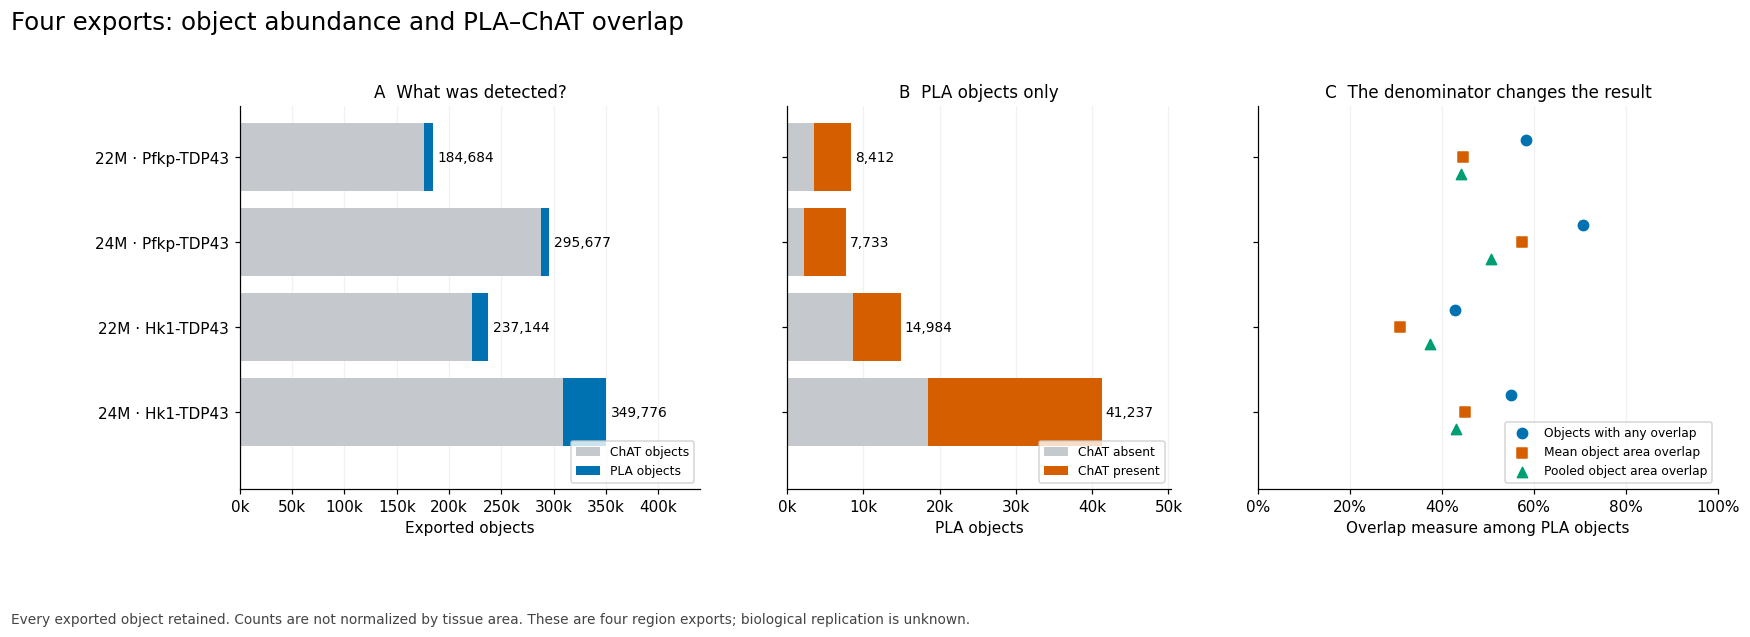

In [6]:
fig_overview, overview_table = overview(objects)
display(overview_table)
show_and_save(fig_overview, '01_overview_denominators', OUTPUT_ROOT)

## 3. Reconstructed spatial atlas for the selected ROI mode

The count reconstruction uses fine bins. Fraction and mean-overlap maps use separate, coarser bins and require a minimum raw PLA denominator. The mode is `ROI_MODE` above; exact exported region/job names appear in the panels. Blank space does not establish the tissue boundary.

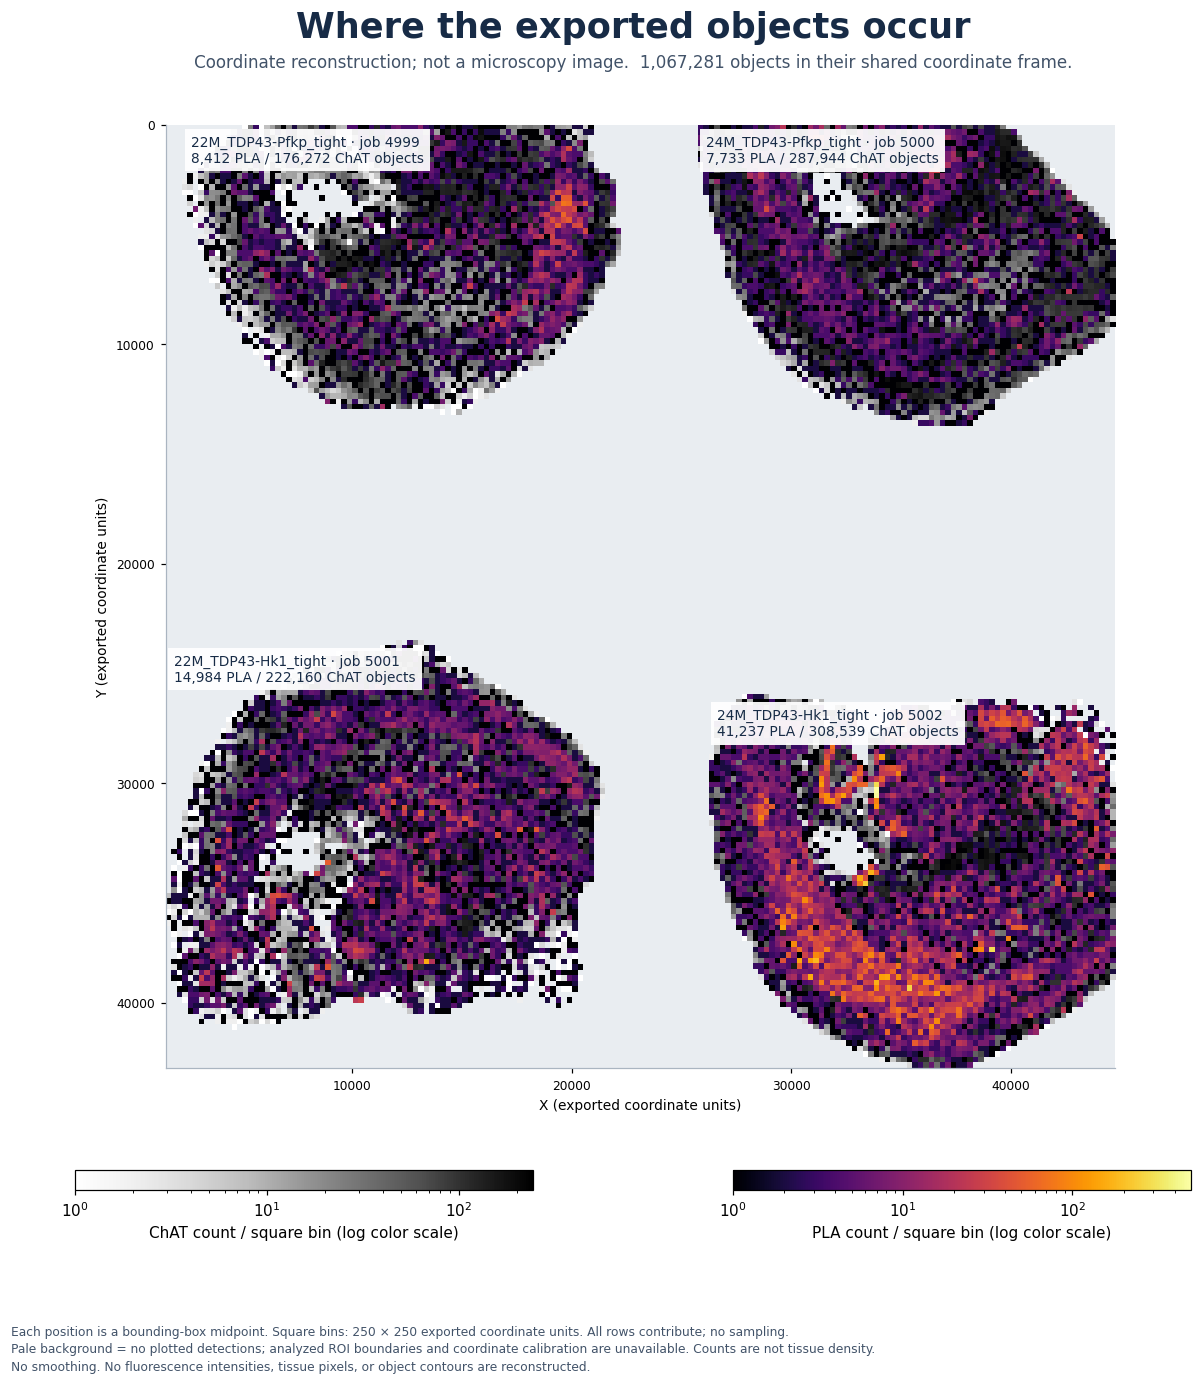

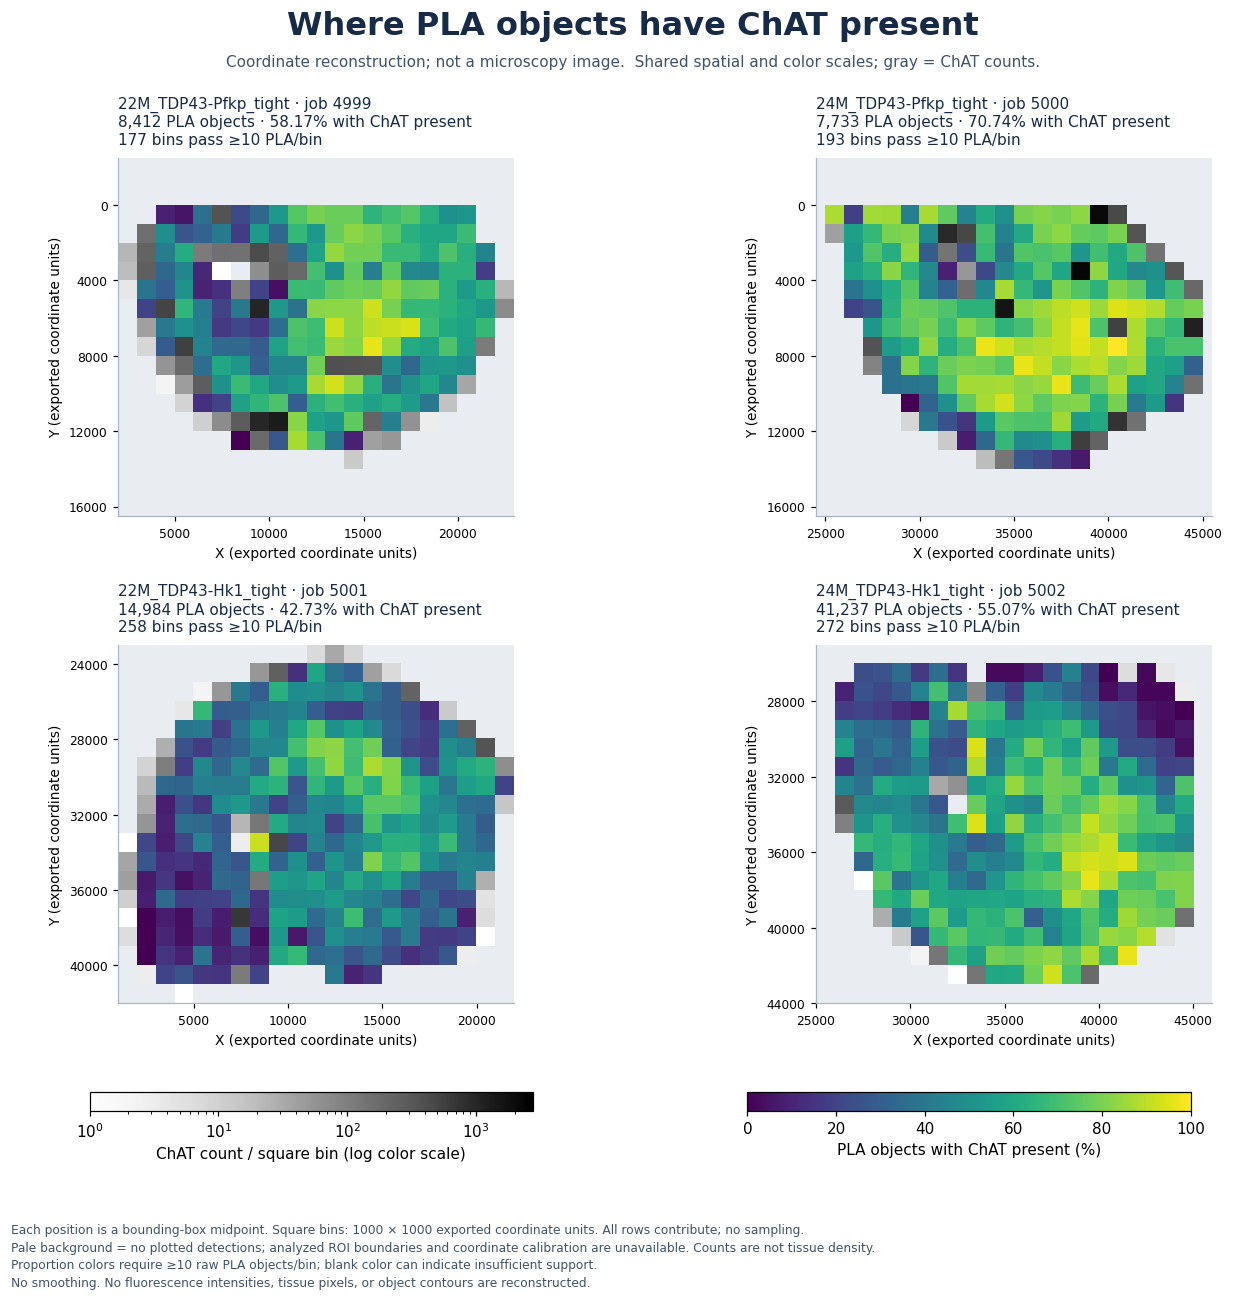

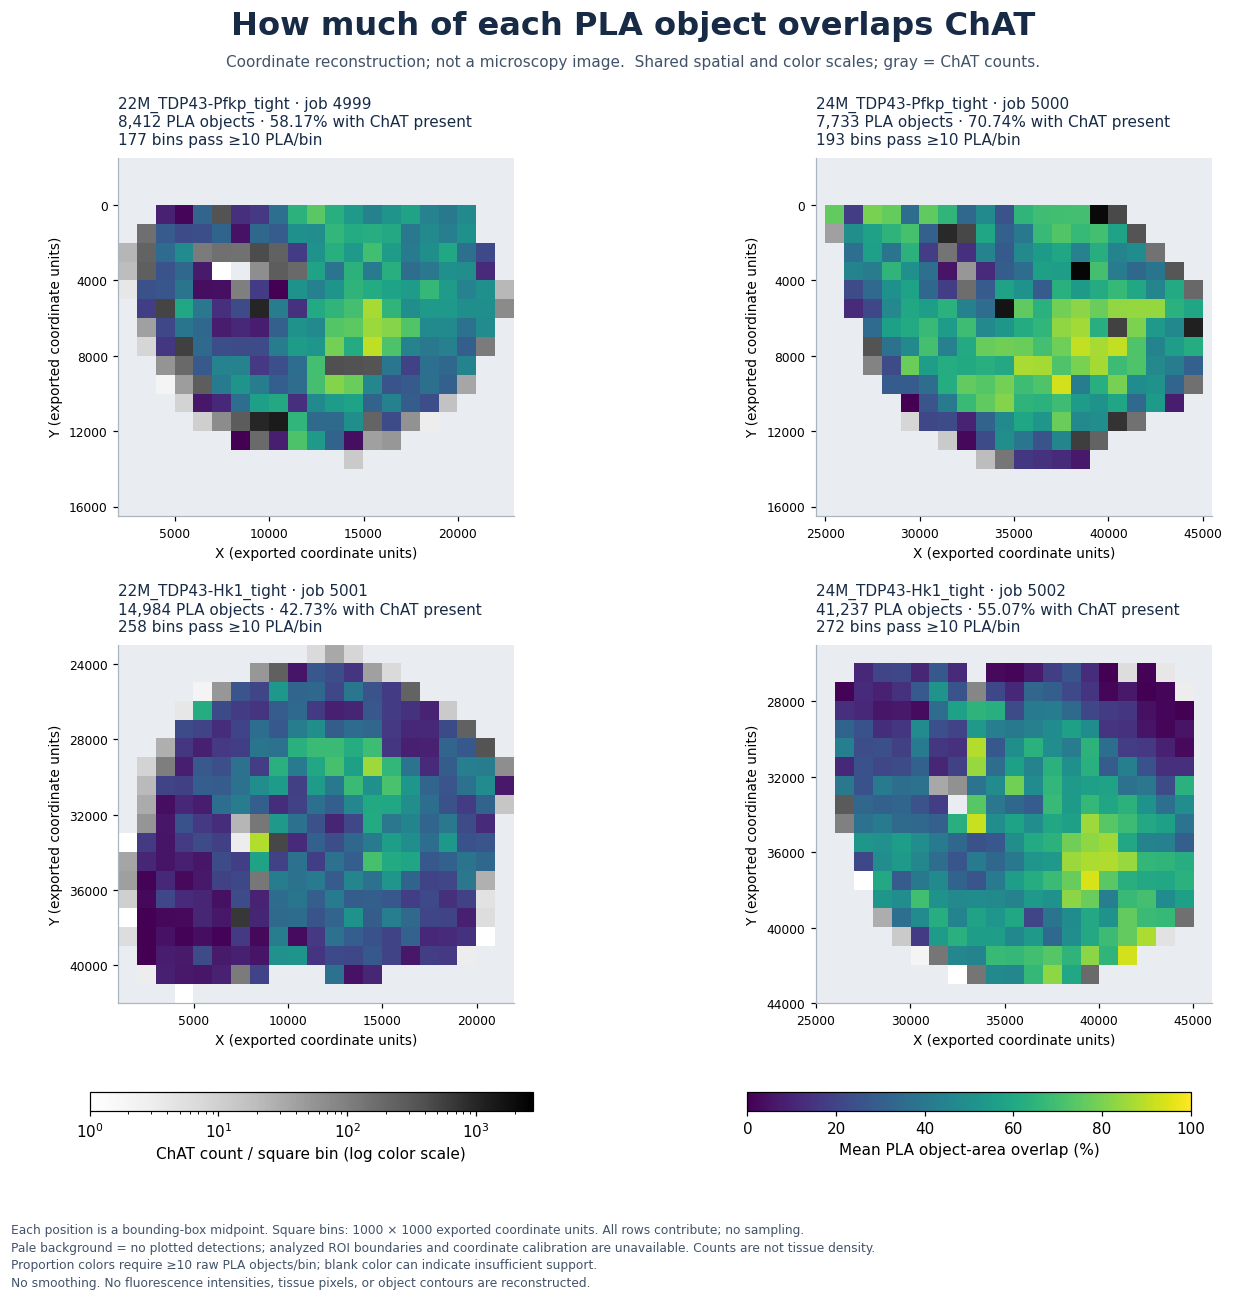

In [7]:
fig_atlas, atlas_table = coordinate_overview(objects, bin_width=SPATIAL_BIN_WIDTH)
show_and_save(fig_atlas, '02_coordinate_reconstruction_PLA_on_ChAT', OUTPUT_ROOT)
spatial_tables = {'coordinate_overview': atlas_table}
for metric, name in [('pla_fraction', '03_heatmap_PLA_fraction_with_ChAT'),
                     ('mean_overlap', '04_heatmap_mean_PLA_overlap')]:
    fig, table = spatial_atlas(objects, metric=metric, bin_width=FRACTION_BIN_WIDTH,
        min_support=MIN_PLA_SUPPORT, smoothing=SPATIAL_SMOOTHING)
    show_and_save(fig, name, OUTPUT_ROOT)
    spatial_tables[metric + '_atlas'] = table

## 4. Detailed overlay for one region

This is the closest possible image-like view from the supplied tables: a selected PLA-derived metric over a grayscale ChAT-count layer, paired with its raw PLA denominator. Hatching marks nonempty bins that do not meet the support threshold.

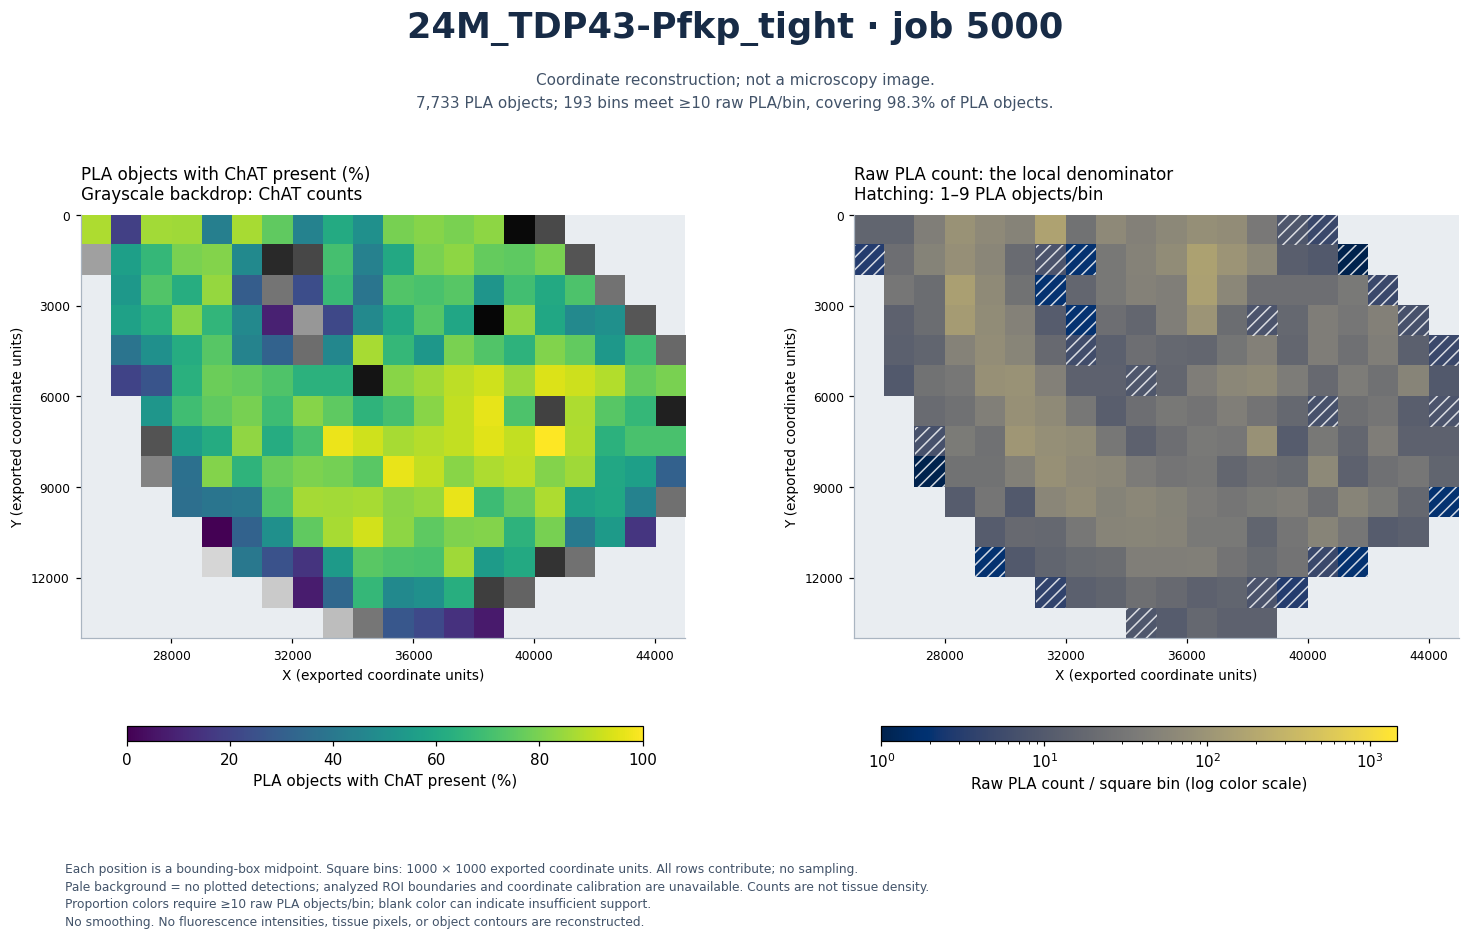

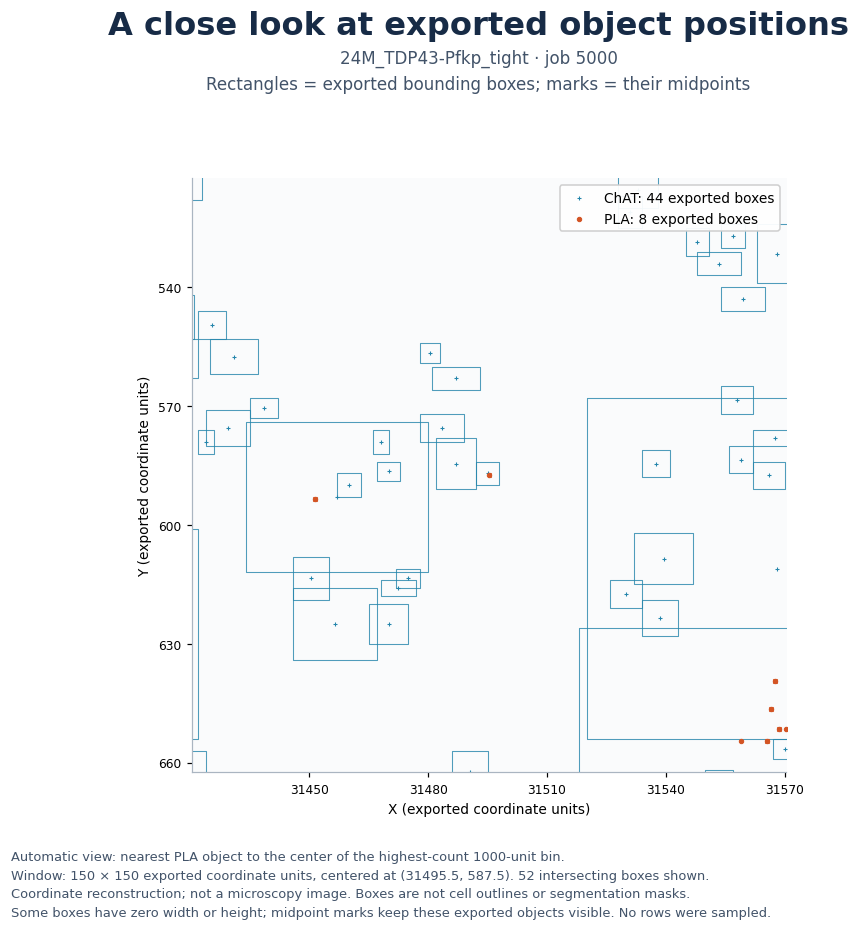

In [8]:
fig_focus, focus_table = region_heatmap(objects, FOCUS_JOB, metric='pla_fraction',
    bin_width=FRACTION_BIN_WIDTH, min_support=MIN_PLA_SUPPORT, smoothing=SPATIAL_SMOOTHING)
show_and_save(fig_focus, f'05_detailed_overlay_job_{FOCUS_JOB}', OUTPUT_ROOT)
spatial_tables['focus_region_fraction'] = focus_table
fig_boxes = bounding_box_zoom(objects, FOCUS_JOB, window=FOCUS_WINDOW)
show_and_save(fig_boxes, f'06_exported_bounding_boxes_job_{FOCUS_JOB}', OUTPUT_ROOT)

## 5. Full distributions and object-level structure

ECDFs preserve the distribution and ties. The overlap composition preserves exact 0% and 100% endpoint masses. Two-dimensional histogram bins show the number of objects at each combination of area and overlap; these are rectangular bins, not image pixels. All views below use the selected ROI mode.

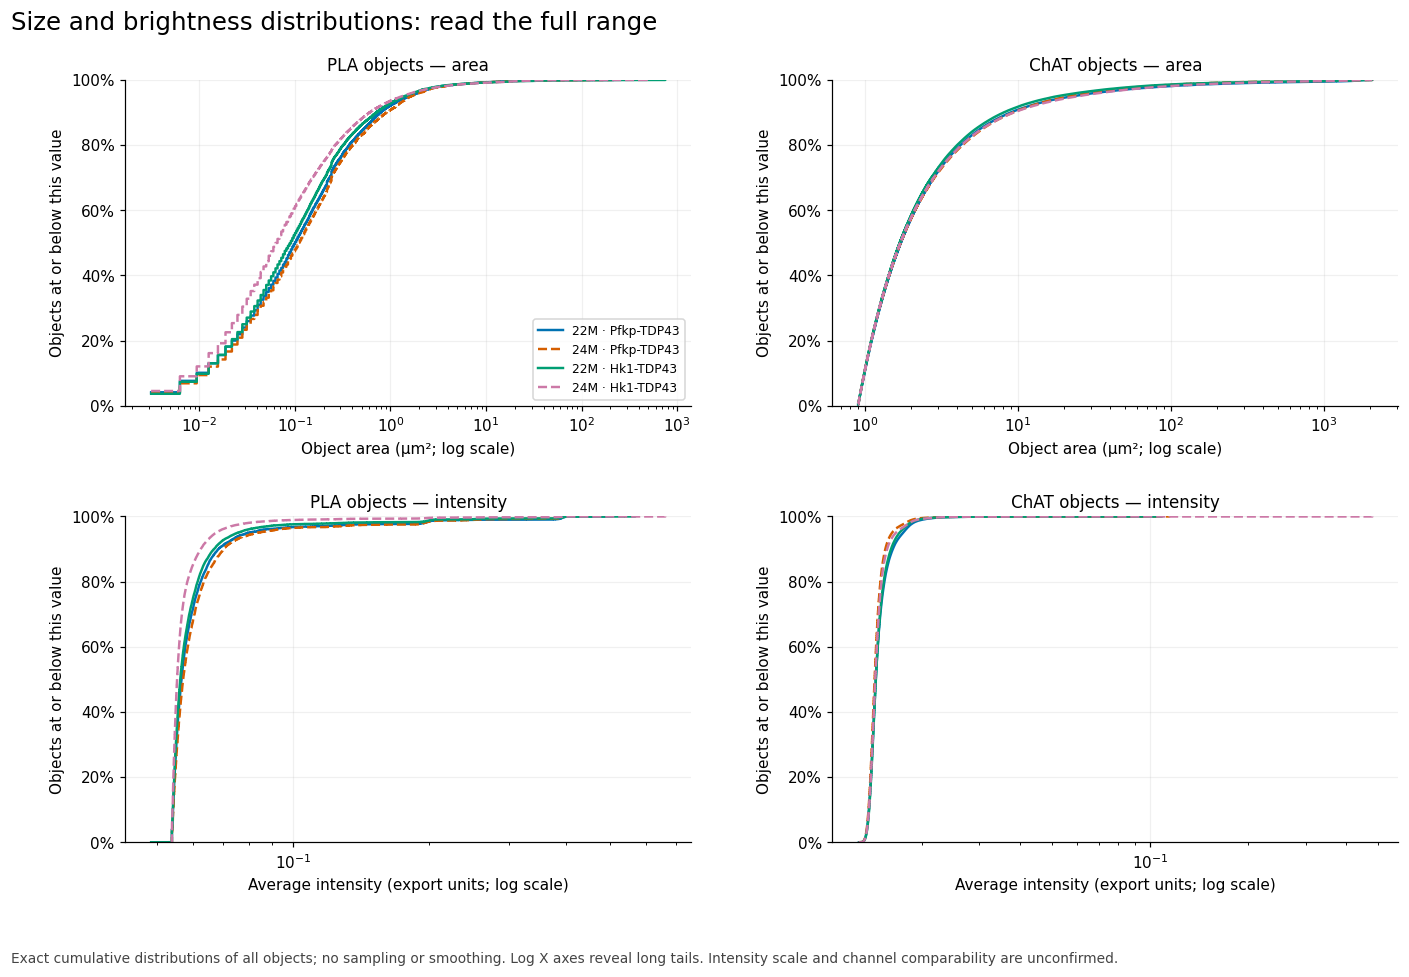

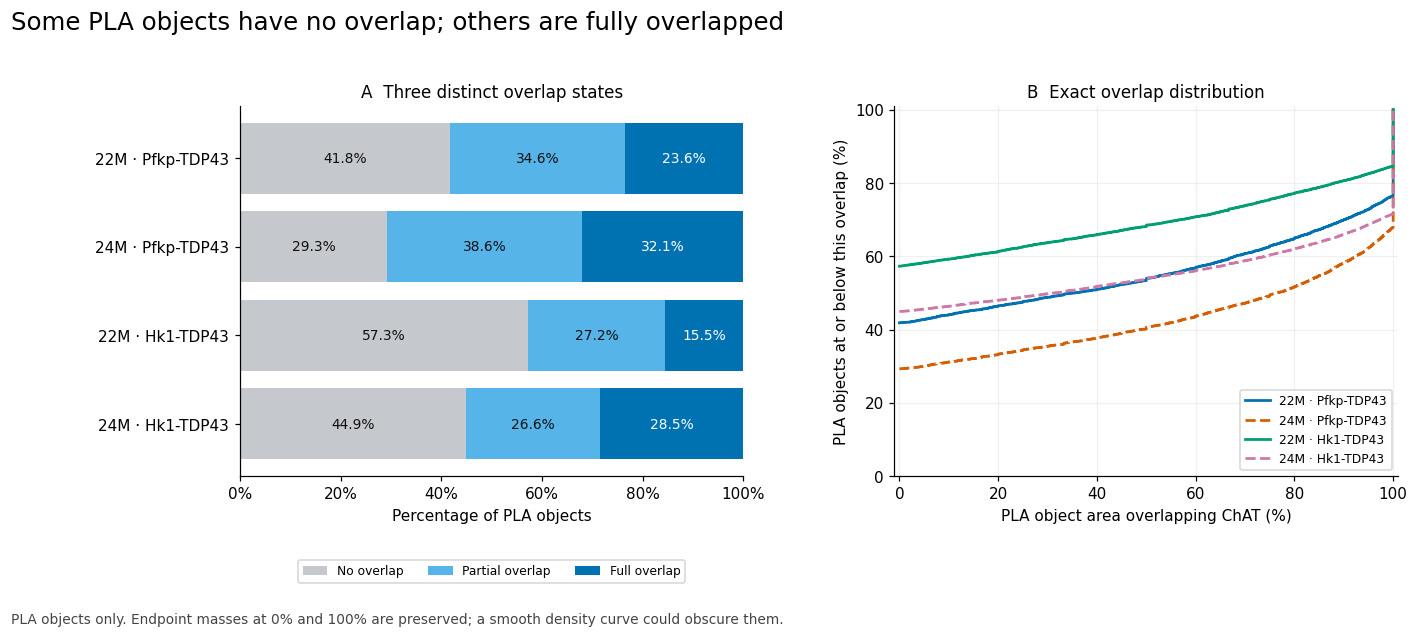

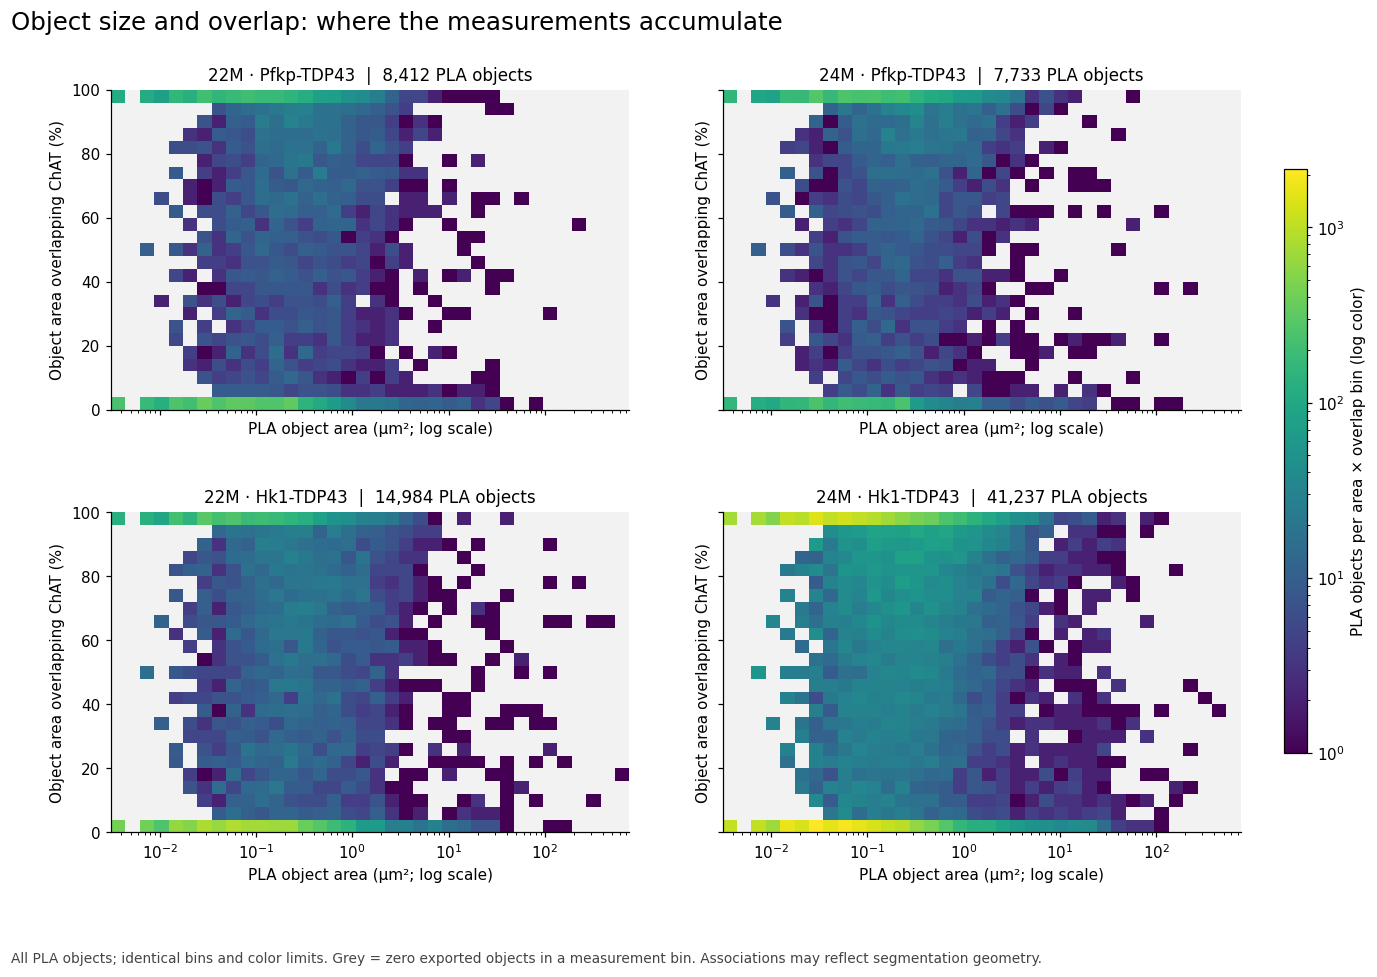

In [9]:
fig_ecdf, ecdf_table = ecdf_figures(objects)
show_and_save(fig_ecdf, '07_size_and_intensity_ecdfs', OUTPUT_ROOT)
fig_overlap, overlap_table = overlap_composition(objects)
show_and_save(fig_overlap, '08_overlap_composition', OUTPUT_ROOT)
fig_size_overlap, size_overlap_table = size_overlap(objects)
show_and_save(fig_size_overlap, '09_size_by_overlap_histogram', OUTPUT_ROOT)

## 6. Quality review and sensitivity analysis

These views are prompts for image and parameter review, not automatic artifact calls. Area-threshold curves show how an eventual size filter could change the result; they do not select a cutoff.

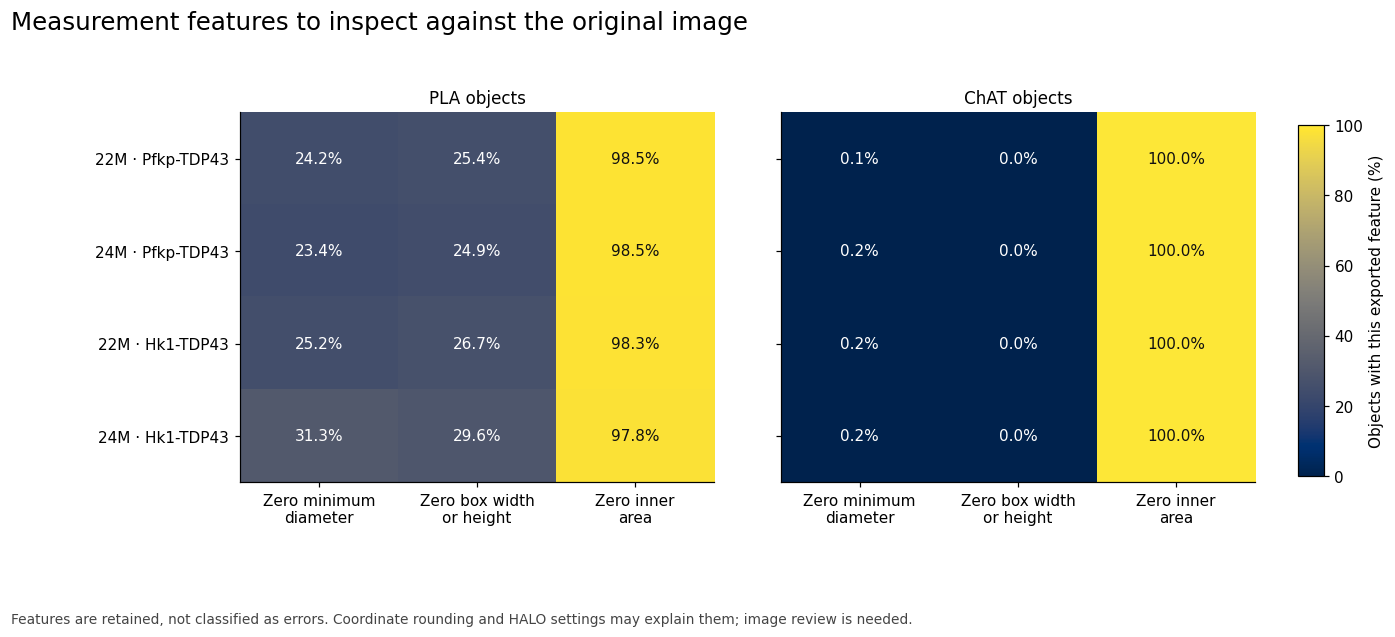

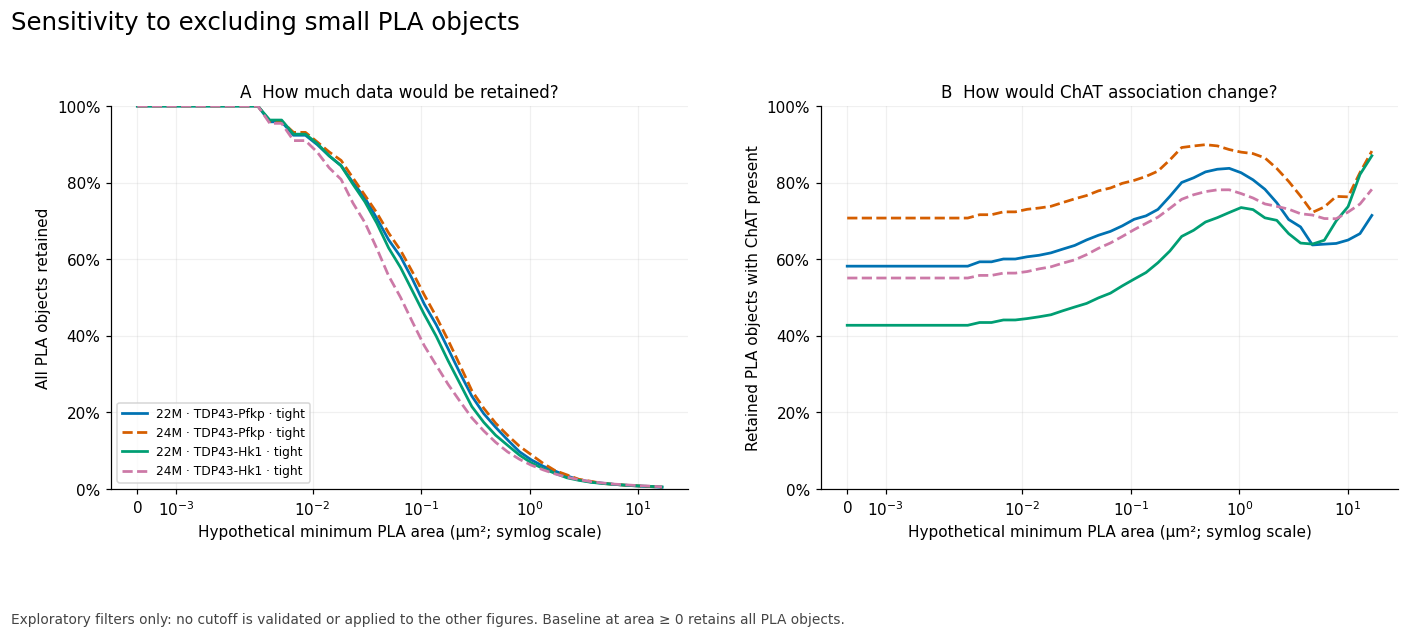

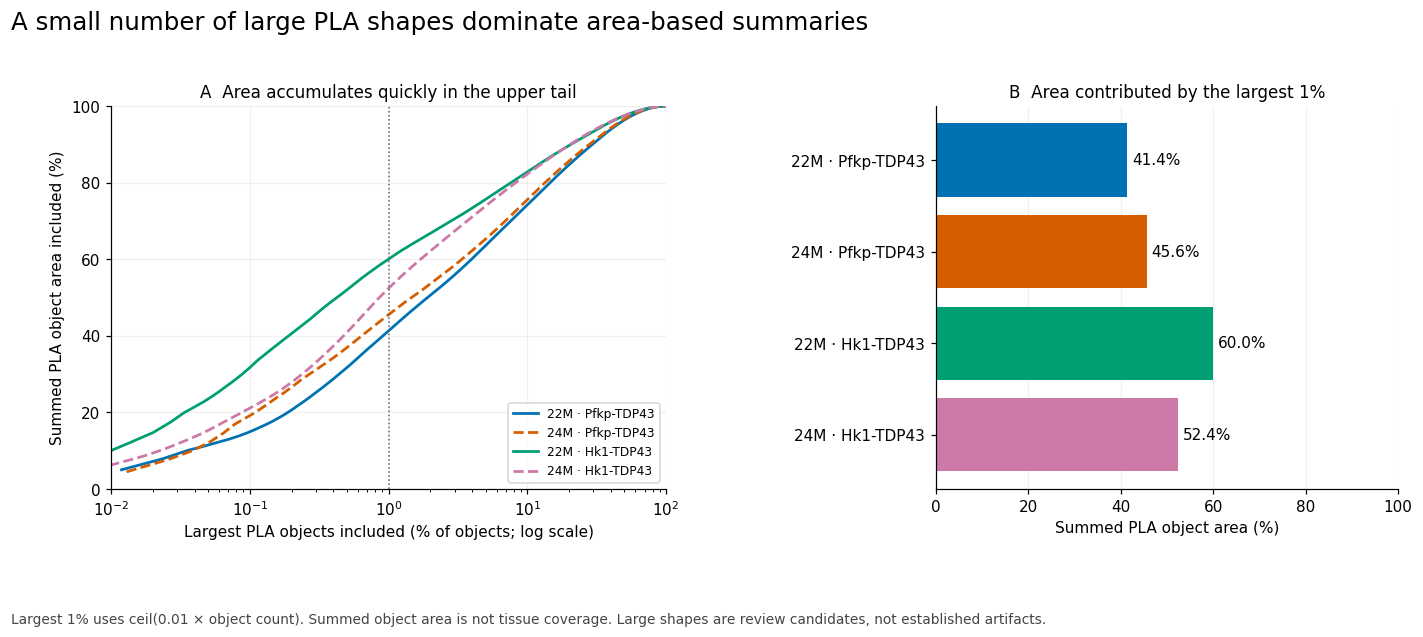

,job,region,object_type,object_id,area,overlap_pct,x,y
0,4999,22M_TDP43-Pfkp_tight,ChAT,130534,2079.45970,0.000000,14290.0,6960.0
1,4999,22M_TDP43-Pfkp_tight,ChAT,157381,2062.58500,0.075869,13330.0,9200.0
2,4999,22M_TDP43-Pfkp_tight,ChAT,128105,2003.37720,0.000000,14610.0,6800.0
3,4999,22M_TDP43-Pfkp_tight,ChAT,125378,1977.78430,0.000000,13650.0,6640.0
4,4999,22M_TDP43-Pfkp_tight,ChAT,145322,1976.85290,0.009360,13170.0,8080.0
...,...,...,...,...,...,...,...,...
75,5002,24M_TDP43-Hk1_tight,PLA,289539,159.60672,12.773356,42427.5,39439.5
76,5002,24M_TDP43-Hk1_tight,PLA,54601,151.25241,15.295142,40886.5,30145.0
77,5002,24M_TDP43-Hk1_tight,PLA,104635,146.27559,8.794271,41575.0,32227.5
78,5002,24M_TDP43-Hk1_tight,PLA,299933,139.39833,83.750650,43043.0,39743.5


In [10]:
fig_qc, qc_table = measurement_qc(objects)
show_and_save(fig_qc, '10_measurement_quality_review', OUTPUT_ROOT)
fig_sensitivity, sensitivity_table = area_sensitivity(objects)
show_and_save(fig_sensitivity, '11_area_filter_sensitivity', OUTPUT_ROOT)
fig_concentration, concentration_tables = area_concentration(objects)
show_and_save(fig_concentration, '12_area_concentration', OUTPUT_ROOT)
largest_objects = top_objects(objects, n=10)
display(largest_objects[['job', 'region', 'object_type', 'object_id', 'area', 'overlap_pct', 'x', 'y']])

## Interactive region explorer

Choose the ROI mode, region, metric, and bin width, then click **Render view**. This view reads the already loaded data and does not change the saved default analyses. A running Jupyter kernel and ipywidgets are needed; the static figures above remain usable without widgets.

In [11]:
import ipywidgets as widgets

def render_view(roi_mode, pair_id, metric, bin_width, min_support):
    selected = all_objects.loc[all_objects.roi_mode == roi_mode]
    job = all_manifest.loc[(all_manifest.roi_mode == roi_mode) & (all_manifest.pair_id == pair_id), 'job'].iloc[0]
    fig, _ = region_heatmap(selected, job, metric=metric, bin_width=bin_width,
        min_support=min_support, smoothing=0)
    display(fig)
    plt.close(fig)

explorer = widgets.interactive(render_view, {'manual': True, 'manual_name': 'Render view'},
    roi_mode=widgets.Dropdown(options=[('Tissue outline', 'outline'), ('Box', 'box')], value=ROI_MODE, description='Selection:'),
    pair_id=widgets.Dropdown(options=all_manifest.pair_id.drop_duplicates().tolist(), value=FOCUS_PAIR, description='Region:'),
    metric=widgets.Dropdown(options=[('PLA count', 'pla_count'), ('PLA with ChAT (%)', 'pla_fraction'), ('Mean area overlap (%)', 'mean_overlap')], description='Metric:'),
    bin_width=widgets.Dropdown(options=[250, 500, 1000, 2000], value=FRACTION_BIN_WIDTH, description='Bin width:'),
    min_support=widgets.IntSlider(min=1, max=50, value=MIN_PLA_SUPPORT, description='Min PLA:', continuous_update=False))
display(explorer)

interactive(children=(Dropdown(description='Selection:', options=(('Tissue outline', 'outline'), ('Box', 'box'…

## 7. Save supporting data and provenance

The exports below contain the values behind the figures, so a reviewer can inspect counts without reverse-engineering pixels from a rendered chart. The raw source CSVs are not copied or altered.

In [12]:
tables = {
    'manifest': manifest, 'summary': summary, 'quality_control': qc,
    'overview': overview_table, 'ecdf': ecdf_table, 'overlap_composition': overlap_table,
    'size_overlap_bins': size_overlap_table, 'area_sensitivity': sensitivity_table,
    'measurement_qc': qc_table, 'largest_objects': largest_objects,
    **concentration_tables, **spatial_tables,
}
sources = pd.DataFrame([
    {'source': 'Input CSVs', 'reference': 'manifest sheet: exact names and SHA-256 hashes'},
    {'source': 'ROI design', 'reference': 'Dataset owner: box vs tissue-outline reruns of the same sections; September 14, 2026'},
    {'source': 'Methods and references', 'reference': 'docs/research_methods.md and docs/tissue_outline_review.md'},
    {'source': 'Spatial boundary effects', 'reference': 'https://www.nature.com/articles/s41467-018-03053-x'},
    {'source': 'Microscopy reporting', 'reference': 'https://www.nature.com/articles/s41592-021-01156-w'},
])
xlsx_path = export_tables(tables, OUTPUT_ROOT, sources=sources)
comparison_tables = {'manifest': all_manifest, 'summary_all': summary_all, 'quality_control_all': qc_all,
    'roi_comparison': roi_table, 'paired_spatial_bins': comparison_grid, 'measurement_signatures': signature_table}
comparison_xlsx = export_tables(comparison_tables, COMPARISON_ROOT, sources=sources)
parameters = {'roi_mode': ROI_MODE, 'count_bin_width': SPATIAL_BIN_WIDTH,
    'fraction_bin_width': FRACTION_BIN_WIDTH, 'minimum_raw_PLA_support': MIN_PLA_SUPPORT,
    'spatial_smoothing_sigma_bins': SPATIAL_SMOOTHING, 'focus_job': FOCUS_JOB,
    'comparison_bin_width': COMPARISON_BIN_WIDTH, 'actual_roi_geometry_available': False}
write_run_metadata(OUTPUT_ROOT, parameters, manifest)
write_run_metadata(COMPARISON_ROOT, {**parameters, 'roi_mode': 'paired box vs outline'}, all_manifest)
print(f'Selected dataset figures and workbook: {OUTPUT_ROOT}')
print(f'Paired comparison figures and workbook: {COMPARISON_ROOT}')

Selected dataset figures and workbook: /Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/outline
Paired comparison figures and workbook: /Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/roi_comparison


## Scientific interpretation and sources

The outline-based exports add a better-defined selection procedure according to the dataset owner. They do **not** add independent specimens, actual ROI polygons, microscopy pixels, calibrated coordinate units, or analyzed tissue area. Keep object counts and object-overlap fractions separate from tissue density.

The eight exports pass the structural checks shown above. Most new PLA measurement signatures are identical to an old signature, but some are not. The outlined tables must therefore be treated as reanalysis outputs, rather than assumed to be a strict subset obtained by deleting old rows. Object IDs restart within each job.

For detailed findings and the evidence behind these choices, see [Tissue outline review](docs/tissue_outline_review.md) and [Scientific methods](docs/research_methods.md). The [SODA study](https://www.nature.com/articles/s41467-018-03053-x) explains why spatial observation boundaries matter; [microscopy reporting guidance](https://www.nature.com/articles/s41592-021-01156-w) explains why acquisition and analysis metadata must accompany image-based comparisons. These support the analysis design, not a biological effect in this dataset.